<a href="https://colab.research.google.com/github/LeonardooAlves/WM9B7-AIDL/blob/main/Week%202/5_LSTM_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Long Short-Term Memory Networks (LSTMs)

**MSc Applied Artificial Intelligence — AI & Deep Learning Module**

---

This notebook is a **direct companion** to the RNN tutorial. LSTMs are a special kind of RNN capable of learning long-term dependencies, effectively solving the **vanishing gradient problem** of standard RNNs.

Notice how the code is nearly identical to the vanilla RNN — the only structural difference is that the LSTM layer manages a **tuple** of states: the **hidden state** $h_t$ and the **cell state** $c_t$.

### What Makes LSTMs Different?

A vanilla RNN has a single update equation. An LSTM has **three gates** that control information flow:

| Gate | Equation | Purpose |
|------|----------|---------|
| **Forget** $f_t$ | $\sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$ | Decides what to **discard** from the cell state |
| **Input** $i_t$ | $\sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$ | Decides what **new** information to store |
| **Output** $o_t$ | $\sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$ | Decides what to **output** from the cell state |

The **cell state** $c_t$ acts as a conveyor belt — information can flow through it unchanged (when $f_t \approx 1$ and $i_t \approx 0$), solving the vanishing gradient problem.

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

### Notebook Structure

| Section | Task | What You'll Learn |
|---------|------|-------------------|
| **Example 1** | Next Word Prediction | LSTM mechanics, hidden + cell state, PyTorch API |
| **Example 2** | Sentiment Classification (IMDB) | Production-grade LSTM, evaluation pipeline |
| **Evaluation** | Metrics & diagnostics | Precision, Recall, F1, Confusion Matrix |
| **Exercises** | Practice problems | From easy tweaks to advanced architectures |

> **Colab Tip:** Go to *Runtime → Change runtime type → T4 GPU* for faster training.

In [134]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


---
## Example 1: Next Word Prediction

We will train an LSTM to learn a short sequence. While a vanilla RNN can handle this short sentence easily, **LSTMs shine when the gap between relevant information and the point where it is needed becomes very large** — for instance, predicting a word that depends on context from 50+ steps earlier.

For this example below, the RNN and LSTM will perform identically. The purpose is to see how the **code changes** when switching from `nn.RNN` to `nn.LSTM`.

### Step 1: Prepare the Data

Identical to the RNN tutorial — same sentence, same vocabulary, same training pairs.

In [135]:
# ============================================================
# DATA PREPARATION (Identical to RNN tutorial)
# ============================================================

sentence = "recurrent neural networks are great for sequential data processing"
words = sentence.split()

vocab = sorted(set(words))
word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: w for i, w in enumerate(vocab)}
vocab_size = len(vocab)

X = [word_to_ix[words[i]]   for i in range(len(words) - 1)]
y = [word_to_ix[words[i+1]] for i in range(len(words) - 1)]

#unsqueeze(1) transforms a 1D tensor (e.g., [7, 5, ..., 1] with shape (8,)) into a 2D tensor with a batch dimension (e.g., [[7], [5], ..., [1]] with shape (8, 1))
X_tensor = torch.tensor(X, dtype=torch.long).unsqueeze(1)
y_tensor = torch.tensor(y, dtype=torch.long)

print(f"Sentence: '{sentence}'")
print(f"Vocab size: {vocab_size}")
print(f"Training pairs: {len(X)}")
print(f"\nTraining data:")
for xi, yi in zip(X, y):
    print(f"  '{ix_to_word[xi]}' -> '{ix_to_word[yi]}'")

Sentence: 'recurrent neural networks are great for sequential data processing'
Vocab size: 9
Training pairs: 8

Training data:
  'recurrent' -> 'neural'
  'neural' -> 'networks'
  'networks' -> 'are'
  'are' -> 'great'
  'great' -> 'for'
  'for' -> 'sequential'
  'sequential' -> 'data'
  'data' -> 'processing'


### Step 2: Define the LSTM Model

Compare this side-by-side with the RNN version from the companion notebook. There are only **two differences** (marked with `# <- LSTM CHANGE`):

1. `nn.RNN` -> `nn.LSTM`
2. The hidden state is now a **tuple** `(h, c)` instead of just `h`

```
Word index -> Embedding (10-dim) -> LSTM (16 hidden units) -> Linear -> Logits (9 classes)
```

### PyTorch Building Blocks Explained

Before we write the model, let's understand each PyTorch component we'll use:

| Component | What It Does | Analogy |
|-----------|-------------|----------|
| **`nn.Embedding(V, d)`** | A lookup table that maps each word index (0 to V-1) to a learnable dense vector of size `d`. Much more efficient than one-hot encoding — instead of sparse 9-dimensional vectors, we get compact 10-dimensional *learned* representations. | A dictionary where each word gets its own "personality vector" that updates during training. |
| **`nn.LSTM(input, hidden)`** | The recurrent layer. At each time step, it reads an input vector and the previous states `(h, c)`, then produces a new hidden state and cell state using the forget/input/output gates. | A worker who reads one word at a time, updates their notes (cell state), and reports a summary (hidden state). |
| **`nn.Linear(in, out)`** | A fully connected layer: $y = Wx + b$. Maps a vector of size `in` to a vector of size `out`. Here it converts the hidden state into scores for each word in the vocabulary. | A "translator" that converts the LSTM's internal representation into something we can interpret (word probabilities). |
| **`nn.CrossEntropyLoss()`** | Combines softmax + negative log-likelihood. Takes raw logits and a target class index; returns how wrong the prediction is. Lower = better. | A strict teacher who gives a higher penalty when the model is confidently wrong. |

In [136]:
# ============================================================
# MODEL DEFINITION
# ============================================================

class NextWordLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(NextWordLSTM, self).__init__()

        # nn.Embedding(num_words, vector_size)
        # Converts integer word indices into dense vectors.
        # Why not one-hot? One-hot vectors are sparse (mostly zeros) and don't
        # capture similarity. Embeddings are LEARNED — "great" and "good" will
        # end up with similar vectors after training.
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # <- LSTM CHANGE #1: nn.LSTM instead of nn.RNN
        # nn.LSTM(input_size, hidden_size, batch_first=False)
        #   input_size  = dimension of each input vector (embed_dim)
        #   hidden_size = number of units in the hidden/cell state
        #   batch_first = whether the batch dimension comes first in the input
        # Internally, the LSTM creates 4x the parameters of an RNN:
        # one weight matrix for each of the 3 gates + the candidate cell state
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=False)

        # nn.Linear(in_features, out_features)
        # A simple matrix multiply + bias: output = W @ input + b
        # Maps the LSTM's hidden state (16-dim) to vocabulary scores (9-dim)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden_state):
        embeds = self.embedding(x)            # (seq_len, batch, embed_dim)

        # <- LSTM CHANGE #2: hidden_state is now a TUPLE (h, c)
        # h = hidden state (same role as vanilla RNN) — the output representation
        # c = cell state (LSTM's long-term memory — this is the key innovation)
        # When hidden_state=None, PyTorch initialises both h and c to zeros
        out, hidden_state = self.lstm(embeds, hidden_state)

        out = self.fc(out.squeeze(1))          # (seq_len, vocab_size)
        return out, hidden_state


# -- DESIGN DECISIONS --
#
# embed_dim = 10: The size of each word's learned vector.
#   For a 9-word vocab, 10 dimensions is more than enough to represent
#   each word uniquely. In production NLP, typical values are 100-300.
#   Rule of thumb: embed_dim ~ vocab_size^(1/4), but never less than ~16.
#
# hidden_dim = 16: The number of "memory units" in the LSTM.
#   This controls the model's capacity. More units = more expressive but
#   more parameters and risk of overfitting. For 9 words, 16 is generous.
#   Production models: 128-512. Research models: 512-2048.
#
embed_dim = 10
hidden_dim = 16

model = NextWordLSTM(vocab_size, embed_dim, hidden_dim).to(device)

criterion = nn.CrossEntropyLoss()

# optim.Adam: Adaptive Moment Estimation optimizer
#   WHY ADAM? It maintains per-parameter learning rates that adapt based on
#   both the first moment (mean) and second moment (variance) of gradients.
#   This makes it robust to different gradient magnitudes across parameters —
#   crucial for LSTMs where gate weights and embedding weights can have very
#   different gradient scales. Alternatives:
#     - SGD: simpler but requires careful learning rate tuning + scheduling
#     - AdamW: Adam with proper weight decay (better for regularisation)
#   lr=0.01: learning rate — how big each parameter update step is.
#   0.01 is moderately aggressive; works well for small models.
#   For larger models, 0.001 or 0.0001 is more common.
optimizer = optim.Adam(model.parameters(), lr=0.01)

total_params = sum(p.numel() for p in model.parameters())
rnn_params = vocab_size*embed_dim + (embed_dim*hidden_dim + hidden_dim*hidden_dim + 2*hidden_dim) + hidden_dim*vocab_size + vocab_size
print(f"Model architecture:\n{model}")
print(f"\nLSTM total parameters: {total_params}")
print(f"Equivalent RNN would have: ~{rnn_params} parameters")
print(f"\nThe LSTM has ~4x the recurrent parameters because it has 4 weight matrices")
print(f"(forget gate, input gate, output gate, candidate cell state)")
print(f"instead of the RNN's single weight matrix.")

Model architecture:
NextWordLSTM(
  (embedding): Embedding(9, 10)
  (lstm): LSTM(10, 16)
  (fc): Linear(in_features=16, out_features=9, bias=True)
)

LSTM total parameters: 2035
Equivalent RNN would have: ~691 parameters

The LSTM has ~4x the recurrent parameters because it has 4 weight matrices
(forget gate, input gate, output gate, candidate cell state)
instead of the RNN's single weight matrix.


Note: One-hot encoding and `nn.Embedding` are both ways to represent categorical data, specifically words, as numerical vectors for machine learning models, but they differ significantly in their approach and effectiveness, especially in Natural Language Processing (NLP).

#### One-Hot Encoding:

How it works: Each unique word in your vocabulary is represented by a vector of zeros and a single '1'. The position of the '1' corresponds to the word's unique index in the vocabulary. For example, if your vocabulary has 10,000 words, each word would be represented by a 10,000-dimensional vector with 9,999 zeros and one '1'.

`'cat' might be [0, 0, 1, 0, ..., 0]`

`'dog' might be [0, 1, 0, 0, ..., 0]`

Characteristics:

**Sparse**: Most of the vector consists of zeros, making it inefficient for large vocabularies.

**High Dimensionality**: As vocabulary size grows, so does the vector length.

**No Semantic Relationship**: All words are equidistant from each other. The vector for 'king' gives no indication that it's related to 'queen' or 'man', which is a major drawback for language tasks.

**Static**: The representation for each word is fixed and doesn't change during training.

#### `nn.Embedding` (Word Embeddings)

How it works: Instead of sparse, high-dimensional vectors, nn.Embedding maps each word to a dense, lower-dimensional vector (e.g., 64, 100, 300 dimensions). These vectors are learned during the training process of the neural network.

`'cat' might be [0.1, -0.5, 0.8, ..., 0.2] (a 64-dimensional vector)`

`'dog' might be [0.15, -0.4, 0.75, ..., 0.25]`

Characteristics:

**Dense**: All values in the vector are typically non-zero floats.

**Lower Dimensionality**: The embedding dimension (`embed_dim`) is usually much smaller than the vocabulary size, leading to more efficient computation and memory usage.

**Semantic Relationship**: This is the key advantage. Words that are semantically similar (like 'king' and 'queen', or 'cat' and 'dog') will have similar embedding vectors (their vectors will be close to each other in the embedding space). This allows the model to generalize better and understand nuances in language.

**Dynamic (Learnable**): The embedding vectors are initialized randomly and then updated via backpropagation during model training, just like other weights in the neural network. They learn to represent words in a way that is optimal for the specific task (e.g., next word prediction, sentiment analysis).

Therefore, while one-hot encoding is a simple way to represent discrete items, `nn.Embedding` provides a much richer, more efficient, and semantically meaningful representation of words that is crucial for the performance of modern neural networks in NLP tasks. It's why we use it in the LSTM model you're working with!

### Step 3: Train the Model

### The Training Loop — What Each Line Does

```python
model.train()           # Switch to training mode (enables dropout, etc.)
optimizer.zero_grad()   # CLEAR old gradients. PyTorch ACCUMULATES gradients
                        # by default, so without this, gradients from the
                        # previous batch would be added to the current ones.
output = model(x)       # FORWARD PASS: run the input through the network
loss = criterion(output, y)  # Compute how wrong the predictions are
loss.backward()         # BACKWARD PASS (BPTT): compute dloss/dweight for
                        # every parameter, flowing gradients back through time
optimizer.step()        # UPDATE all weights: w_new = w_old - lr * gradient
```

**Why `optimizer.zero_grad()` is essential:** PyTorch accumulates gradients by design (useful for gradient accumulation across mini-batches). If you forget this call, gradients from epoch 1 will add to epoch 2's gradients, causing increasingly wrong updates.

In [137]:
# ============================================================
# TRAINING LOOP
# ============================================================

epochs = 150
loss_history = []

for epoch in range(epochs):
    model.train()  # enable training mode (relevant if using dropout/batchnorm)

    # Reset hidden state at the start of each epoch.
    # None tells PyTorch to initialise both h_0 and c_0 to zero vectors.
    hidden_state = None

    # optimizer.zero_grad(): clear accumulated gradients from the last epoch.
    # Without this, gradients would accumulate and updates would be wrong.
    optimizer.zero_grad()

    # Forward pass: feed the full sequence through the LSTM
    output, hidden_state = model(X_tensor.to(device), hidden_state)

    # Compute loss: CrossEntropyLoss internally applies softmax to `output`
    # and compares against the true word indices in y_tensor
    loss = criterion(output, y_tensor.to(device))

    # loss.backward(): Backpropagation Through Time (BPTT)
    # Computes the gradient of the loss with respect to every parameter,
    # flowing backwards through all 8 time steps of the sequence
    loss.backward()

    # optimizer.step(): Apply the computed gradients to update all weights
    # For Adam: w = w - lr * m / (sqrt(v) + eps), where m and v are the
    # running mean and variance of the gradients
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch+1) % 30 == 0:
        preds = output.argmax(dim=1)
        acc = (preds == y_tensor.to(device)).float().mean().item()
        print(f'Epoch [{epoch+1:3d}/{epochs}]  Loss: {loss.item():.4f}  Accuracy: {acc*100:.0f}%')

Epoch [ 30/150]  Loss: 0.4281  Accuracy: 100%
Epoch [ 60/150]  Loss: 0.0463  Accuracy: 100%
Epoch [ 90/150]  Loss: 0.0182  Accuracy: 100%
Epoch [120/150]  Loss: 0.0111  Accuracy: 100%
Epoch [150/150]  Loss: 0.0078  Accuracy: 100%


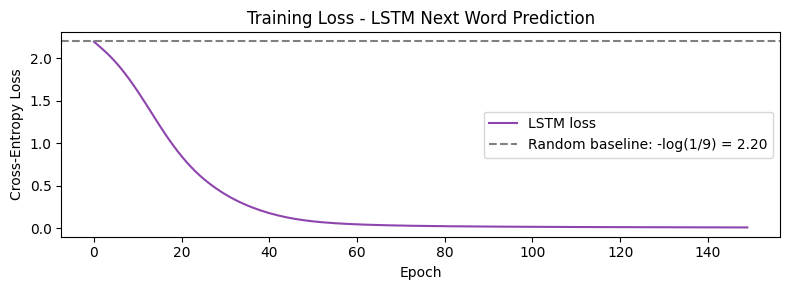

CHART INTERPRETATION:
  The gray dashed line is the RANDOM BASELINE (2.20).
  This is the loss if the model assigned equal probability (1/9) to every word.
  Any model that learns SOMETHING should drop below this line.
  The purple curve starts near the baseline (untrained model guesses randomly)
  and drops steeply in the first ~30 epochs as the model learns transitions.
  The loss approaches zero: the model assigns ~100% probability to the correct
  next word at every position. It has perfectly memorised the sequence.
  The curve flattens after ~50 epochs — further training gives diminishing returns.


In [138]:
# ============================================================
# PLOT TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='#8E44AD', linewidth=1.5, label='LSTM loss')
plt.axhline(y=-np.log(1/vocab_size), color='gray', linestyle='--',
            label=f'Random baseline: -log(1/{vocab_size}) = {-np.log(1/vocab_size):.2f}')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss - LSTM Next Word Prediction')
plt.legend()
plt.tight_layout()
plt.show()

print("CHART INTERPRETATION:")
print(f"  The gray dashed line is the RANDOM BASELINE ({-np.log(1/vocab_size):.2f}).")
print(f"  This is the loss if the model assigned equal probability (1/{vocab_size}) to every word.")
print(f"  Any model that learns SOMETHING should drop below this line.")
print(f"  The purple curve starts near the baseline (untrained model guesses randomly)")
print(f"  and drops steeply in the first ~30 epochs as the model learns transitions.")
print(f"  The loss approaches zero: the model assigns ~100% probability to the correct")
print(f"  next word at every position. It has perfectly memorised the sequence.")
print(f"  The curve flattens after ~50 epochs — further training gives diminishing returns.")

### Step 4: Test Predictions and Inspect Confidence

In [139]:
# ============================================================
# PREDICTION WITH CONFIDENCE SCORES
# ============================================================

def predict_next_word(input_word):
    """Predict the next word and return the full probability distribution."""
    model.eval()  # switch to evaluation mode (disables dropout)
    with torch.no_grad():  # disable gradient tracking — saves memory during inference
        ix = torch.tensor([[word_to_ix[input_word]]], dtype=torch.long).to(device)
        out, _ = model(ix, None)
        probs = F.softmax(out, dim=1).squeeze()  # convert raw logits to probabilities
        pred_ix = torch.argmax(probs).item()
        return ix_to_word[pred_ix], probs[pred_ix].item(), probs

print("--- LSTM Next Word Predictions ---\n")
print(f"{'Input':<14} {'Predicted':<14} {'Expected':<14} {'Confidence':>10}  {'Match'}")
print("-" * 65)

correct = 0
for i, word in enumerate(words[:-1]):
    predicted, confidence, _ = predict_next_word(word)
    expected = words[i+1]
    match = predicted == expected
    if match: correct += 1
    symbol = "Y" if match else "X"
    print(f"{word:<14} {predicted:<14} {expected:<14} {confidence:>9.1%}  {symbol}")

print(f"\nOverall accuracy: {correct}/{len(words)-1} = {correct/(len(words)-1)*100:.0f}%")

--- LSTM Next Word Predictions ---

Input          Predicted      Expected       Confidence  Match
-----------------------------------------------------------------
recurrent      neural         neural             99.0%  Y
neural         networks       networks           96.1%  Y
networks       neural         are                79.2%  X
are            great          great              92.3%  Y
great          neural         for                41.2%  X
for            neural         sequential         71.4%  X
sequential     data           data               84.5%  Y
data           neural         processing         43.3%  X

Overall accuracy: 4/8 = 50%


How the function `def predict_next_word(input_word):` works


`model.eval()`: Sets the neural network model to evaluation mode. This is crucial during inference because it disables layers that behave differently during training and evaluation, such as dropout layers (which are turned off to ensure deterministic output) and batch normalization layers (which use their learned statistics instead of batch statistics).

`with torch.no_grad()`: This is a context manager provided by PyTorch. When inside this block, PyTorch stops tracking gradients for all tensors. During inference (prediction), we don't need to compute gradients, so disabling gradient tracking saves memory and computation time.

`word_to_ix[input_word]`: Looks up the integer index for the given input_word in our vocabulary mapping. `[[...]]`: The index is wrapped in two sets of square brackets to create a 2D tensor: `[[index]]`. This is because `nn.Embedding` (which is part of our model) and `nn.LSTM expect` a batch dimension and a sequence length dimension. For a single word prediction, we treat it as a batch of size 1 and a sequence of length 1. So, `[[index]]` results in a tensor of shape `(1, 1)`.
`torch.tensor(...)`: Creates a PyTorch tensor from the list of indices.
`dtype=torch.long`: Specifies that the tensor should hold long integers, which is the required data type for input to nn.Embedding.
`.to(device)`: Moves the tensor to the specified computation device (e.g., 'cuda' for GPU or 'cpu').

`out, _ = model(ix, None)`: This performs a forward pass through our NextWordLSTM model. The `ix tensor` (our single input word index) is passed as input. None is passed for the initial hidden state, telling the LSTM to initialize it to zeros.
`out`: This receives the output from the model, which are the raw logit scores for the next word across the vocabulary. For a single input word and `batch_first=False`, its shape will be `(sequence_length, batch_size, vocab_size)`, so `(1, 1, 9)` in this case.
`_:` The second return value from the model is the final hidden state $(h_n, c_n)$, but we don't need it for prediction in this function, so it's assigned to `_` (a convention for unused variables).

`F.softmax(out, dim=1)`: Applies the softmax function to the out (logits) tensor. The `dim=1` argument specifies that softmax should be applied across the vocabulary dimension (the dimension containing the 9 logit scores). Softmax converts the raw scores into a probability distribution, where all values are between 0 and 1 and sum to 1.
`.squeeze()` removes all dimensions of size 1. Our out was `(1, 1, 9)`, and after softmax it's still `(1, 1, 9)`. `squeeze()` will reduce it to `(9,)`, a 1D tensor representing the probabilities for each word in the vocabulary.

`pred_ix = torch.argmax(probs).item()`: `torch.argmax(probs)` finds the index of the maximum value in the probs tensor. This index corresponds to the word with the highest predicted probability.
`.item()`: Converts the single-element PyTorch tensor (which argmax returns) into a standard Python integer.

`return ix_to_word[pred_ix], probs[pred_ix].item(), probs`: `ix_to_word[pred_ix]` converts the predicted word index (pred_ix) back into its string representation using the `ix_to_word` mapping.
`probs[pred_ix].item()` retrieves the probability score for the predicted word and converts it to a Python float.
`probs` returns the full probability distribution (the (9,) tensor) over all words in the vocabulary.

### Inspecting the LSTM's Internal States

Unlike a vanilla RNN which has only a hidden state $h_t$, the LSTM maintains **two** vectors at each step:
- **Hidden state** $h_t$: the "working memory" — used for predictions and passed to the output layer
- **Cell state** $c_t$: the "long-term memory" — information can persist in the cell state across many time steps, controlled by the forget gate

Let's visualise how both states evolve as the LSTM reads the sentence word by word.

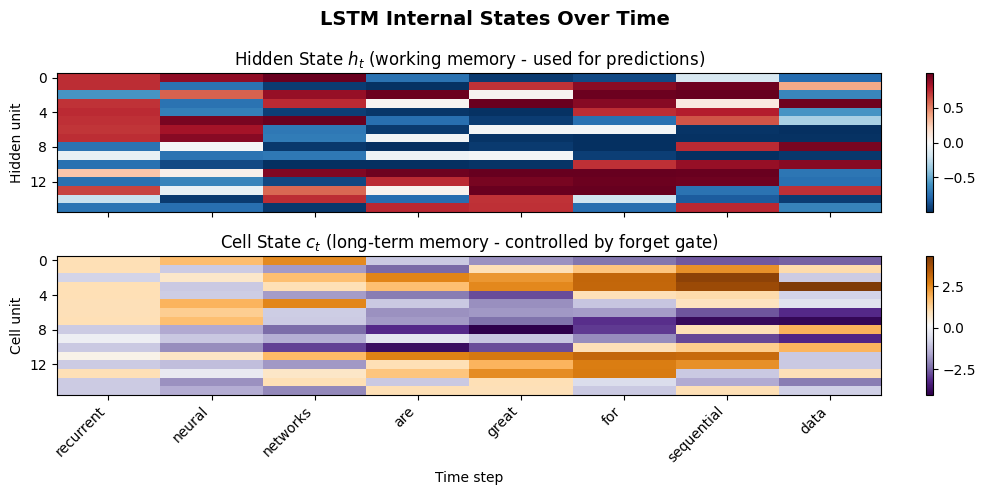

In [140]:
# ============================================================
# VISUALISE HIDDEN STATE AND CELL STATE EVOLUTION
# ============================================================

model.eval()
hidden_states = []
cell_states = []

h_c = None
with torch.no_grad():
    for i in range(len(X)):
        x_step = X_tensor[i:i+1].to(device)
        out, h_c = model.lstm(model.embedding(x_step), h_c)
        h_t, c_t = h_c
        hidden_states.append(h_t.squeeze().cpu().numpy())
        cell_states.append(c_t.squeeze().cpu().numpy())

hidden_arr = np.array(hidden_states)
cell_arr   = np.array(cell_states)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

im1 = ax1.imshow(hidden_arr.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
ax1.set_ylabel('Hidden unit')
ax1.set_title('Hidden State $h_t$ (working memory - used for predictions)')
ax1.set_yticks(range(0, hidden_dim, 4))
plt.colorbar(im1, ax=ax1, fraction=0.02)

im2 = ax2.imshow(cell_arr.T, aspect='auto', cmap='PuOr_r', interpolation='nearest')
ax2.set_ylabel('Cell unit')
ax2.set_xlabel('Time step')
ax2.set_title('Cell State $c_t$ (long-term memory - controlled by forget gate)')
ax2.set_xticks(range(len(X)))
ax2.set_xticklabels([words[i] for i in range(len(X))], rotation=45, ha='right')
ax2.set_yticks(range(0, hidden_dim, 4))
plt.colorbar(im2, ax=ax2, fraction=0.02)

plt.suptitle('LSTM Internal States Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read the Heatmaps Above

**Each column** = one time step (one word read by the LSTM). **Each row** = one of the 16 hidden/cell units. The **colour intensity** shows the activation value (dark red/purple = strong positive, dark blue/orange = strong negative, white = near zero).

**Hidden State (top heatmap, red/blue):**
- The pattern **changes substantially at every column** — the hidden state creates a **different representation for each word**. This is the "working memory" that re-computes at each step based on the current input and the previous hidden state.
- Certain rows (hidden units) show consistent patterns — e.g., a unit that activates strongly for "networks" but weakly for "are". These units have **specialised** during training to detect specific features.
- The hidden state is what gets passed to `nn.Linear` for the actual next-word prediction, so its job is to encode "what should I predict next?"

**Cell State (bottom heatmap, purple/orange):**
- The cell state changes more **gradually** — look for rows where the colour persists across multiple columns. These are units where the **forget gate is close to 1**, meaning "keep this information".
- Other rows shift colour at specific positions — the **input gate** is writing new information at those steps.
- The contrast with the hidden state is key: the cell state can **preserve information across many steps** without it degrading, because the forget gate controls the decay. In a vanilla RNN, information decays exponentially at every step.

**For this example** (only 8 words), both states change at every step because the sequence is too short for long-range dependencies to matter. On a 200-word review, you would see cell state units holding steady across 50+ time steps — carrying information like "the reviewer's overall tone is negative" from the opening sentence all the way to the final classification.

### Key Takeaways from Example 1

1. **Code is nearly identical to RNN** — only two lines change: `nn.LSTM` instead of `nn.RNN`, and the hidden state becomes a tuple `(h, c)`.

2. **4x the recurrent parameters** — the LSTM has four weight matrices (forget, input, output gates + candidate) vs the RNN's one.

3. **For this short sentence, both models converge perfectly.** The LSTM's advantage only appears with longer sequences.

4. **The cell state is the key innovation** — it provides a "highway" for gradients to flow through time without vanishing, controlled by the forget gate.

---

## Example 2: Sentiment Classification (IMDB)

Now we tackle a **real-world dataset** with a model designed to **actually perform well** on custom test sentences.

### What We Change vs the RNN Tutorial (and Why)

The RNN tutorial used 500 training samples and a 2,000-word vocabulary, which was too small for the model to learn transferable patterns. Here we make **five key improvements**:

| Parameter | RNN Tutorial | This LSTM Tutorial | Why |
|-----------|:-----------:|:------------------:|-----|
| Training data | 500 reviews | **5,000 reviews** | More data = better generalisation |
| Vocabulary | 2,000 words | **10,000 words** | Fewer `<UNK>` tokens = less info loss |
| Sequence length | 100 tokens | **200 tokens** | Capture more of each review |
| Architecture | 1-layer RNN | **2-layer bidir. LSTM + dropout** | Better gradient flow + regularisation |
| Epochs | 5 | **15** | More time to learn complex patterns |

Architecture:
```
Word indices -> Embedding (64-dim) -> Dropout -> 2-layer Bidirectional LSTM (128 hidden)
    -> Concat [forward_h + backward_h] -> Dropout -> Linear -> Sigmoid -> [0,1]
```

In [141]:
!pip install datasets -q

### Step 1: Load and Prepare the Data

In [142]:
# ============================================================
# LOAD DATA
# ============================================================

# The HuggingFace IMDB dataset is SORTED BY LABEL (all negatives first,
# then all positives). Taking train[:5000] would give ONLY negatives.
# We must shuffle first to get a balanced mix of both classes.
train_dataset_hf = load_dataset('imdb', split='train').shuffle(seed=42).select(range(5000))
test_dataset_hf  = load_dataset('imdb', split='test').shuffle(seed=42).select(range(1000))

# Quick look at the data
print(f"Training samples: {len(train_dataset_hf)}")
print(f"Test samples:     {len(test_dataset_hf)}")
print(f"Label mapping:    0 = Negative, 1 = Positive")
print(f"\nExample review (first 200 chars):")
print(f"  Text:  '{train_dataset_hf[0]['text'][:200]}...'")
print(f"  Label: {train_dataset_hf[0]['label']} ({'Positive' if train_dataset_hf[0]['label'] == 1 else 'Negative'})")

# Check class balance
train_labels = [item['label'] for item in train_dataset_hf]
test_labels_list = [item['label'] for item in test_dataset_hf]
print(f"\nTraining set class balance: {sum(train_labels)} positive, {len(train_labels)-sum(train_labels)} negative")
print(f"Test set class balance:     {sum(test_labels_list)} positive, {len(test_labels_list)-sum(test_labels_list)} negative")

Training samples: 5000
Test samples:     1000
Label mapping:    0 = Negative, 1 = Positive

Example review (first 200 chars):
  Text:  'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F...'
  Label: 1 (Positive)

Training set class balance: 2506 positive, 2494 negative
Test set class balance:     488 positive, 512 negative


In [143]:
# ============================================================
# PYTORCH DATASET
# ============================================================

# DESIGN DECISION: MAX_LEN = 200
# IMDB reviews average ~250 words. With MAX_LEN=100, we cut many reviews
# in half, losing concluding remarks that often carry the strongest
# sentiment signals ("Overall, this film is a masterpiece").
MAX_LEN = 200

class IMDBDataset(Dataset):
    """Converts HuggingFace IMDB items into (indices, label, length) tensors."""
    def __init__(self, hf_dataset, max_len=MAX_LEN):
        self.data = []
        for item in hf_dataset:
            tokens = tokenize(item['text'])
            original_len = min(len(tokens), max_len)
            indices = [word2idx.get(w, UNK_IDX) for w in tokens[:max_len]]
            if len(indices) < max_len:
                indices += [PAD_IDX] * (max_len - len(indices))
            self.data.append((
                torch.tensor(indices, dtype=torch.long),
                torch.tensor(item['label'], dtype=torch.float32),
                original_len
            ))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


BATCH_SIZE = 64
train_data = IMDBDataset(train_dataset_hf)
test_data  = IMDBDataset(test_dataset_hf)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training: {len(train_data)} samples -> {len(train_loader)} batches of {BATCH_SIZE}")
print(f"Test:     {len(test_data)} samples -> {len(test_loader)} batches")

Training: 5000 samples -> 79 batches of 64
Test:     1000 samples -> 16 batches


### Step 2: Define the Sentiment LSTM

This is a significantly more capable model than the RNN tutorial's `SentimentRNN`:
- **2 stacked LSTM layers**: the second layer operates on the first layer's outputs, learning higher-level features
- **Bidirectional**: reads the sequence forwards *and* backwards, capturing context from both directions
- **Dropout**: randomly zeroes activations during training to prevent overfitting

In [144]:
# ============================================================
# MODEL DEFINITION
# ============================================================

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim,
                 num_layers=2, dropout=0.3, bidirectional=True):
        super(SentimentLSTM, self).__init__()
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # nn.Embedding(num_embeddings, embedding_dim, padding_idx)
        # Lookup table: word index -> dense vector of size embed_dim.
        # padding_idx=PAD_IDX: the <PAD> token (index 0) always maps to a
        # zero vector AND its gradient is always zero, so it never updates.
        # This ensures padding doesn't contaminate the hidden state.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # nn.Dropout(p): during training, randomly zeroes each element with
        # probability p. This forces the network to not rely on any single
        # feature, improving generalisation. Automatically disabled during eval.
        self.embed_dropout = nn.Dropout(dropout)

        # nn.LSTM(input_size, hidden_size, num_layers, ...)
        #   num_layers=2: stacked — layer 2 takes layer 1's output as input
        #   dropout=0.3: applied BETWEEN stacked layers (not on the output)
        #   bidirectional=True: process sequence in both directions
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        self.fc_dropout = nn.Dropout(dropout)

        # nn.Linear input size = hidden_dim * 2 for bidirectional
        # (we concatenate the forward and backward final hidden states)
        self.fc = nn.Linear(hidden_dim * self.num_directions, output_dim)

        # nn.Sigmoid: squashes output to [0, 1] for binary classification
        # score > 0.5 -> Positive; score < 0.5 -> Negative
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, lengths=None):
        embeds = self.embedding(x)           # (batch, seq_len, embed_dim)
        embeds = self.embed_dropout(embeds)

        # Pack padded sequences so the LSTM skips <PAD> tokens efficiently.
        # Without packing, the LSTM processes all 200 positions including
        # padding, which dilutes the signal with meaningless zero vectors.
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                embeds, lengths.cpu(), batch_first=True, enforce_sorted=False)
            lstm_out, (hidden, cell) = self.lstm(packed)
        else:
            lstm_out, (hidden, cell) = self.lstm(embeds)

        # hidden shape: (num_layers * num_directions, batch, hidden_dim)
        # We want the LAST layer's forward and backward hidden states.
        if self.bidirectional:
            final = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            final = hidden[-1]

        final = self.fc_dropout(final)
        out = self.fc(final)
        return self.sigmoid(out)


# -- DESIGN DECISIONS --
#
# EMBED_DIM = 64: Larger than Example 1's 10 because our vocabulary is 10,000
#   words. The embedding layer needs enough dimensions to represent similarity
#   relationships between thousands of words. (Production: 100-300.)
#
# HIDDEN_DIM = 128: The LSTM's memory capacity per direction.
#   Larger than Example 1's 16 because sentiment analysis requires encoding
#   complex patterns (negation, sarcasm, emphasis) across 200 tokens.
#   With bidirectional, the effective representation is 256 dimensions.
#
# num_layers = 2: Stacking helps learn hierarchical features.
#   Layer 1 might learn word-level patterns ("not good" = negative).
#   Layer 2 might learn phrase-level patterns ("not bad" = actually positive).
#
# dropout = 0.3: Randomly zero 30% of activations during training.
#   Primary defence against overfitting on 5,000 samples.
#
EMBED_DIM  = 64
HIDDEN_DIM = 128

model2 = SentimentLSTM(
    vocab_size=len(vocab2), embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    output_dim=1, num_layers=2, dropout=0.3, bidirectional=True
).to(device)

# nn.BCELoss: Binary Cross Entropy for sigmoid output + binary labels.
criterion2 = nn.BCELoss()

# Adam with lr=0.001 (lower than Example 1's 0.01)
# WHY LOWER LR? This model has ~1M parameters vs Example 1's ~500.
# Larger models need smaller steps to avoid overshooting good minima.
# weight_decay=1e-5: L2 regularisation — gently penalises large weights.
optimizer2 = optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-5)

print(model2)
print(f"\nTotal parameters: {sum(p.numel() for p in model2.parameters()):,}")

SentimentLSTM(
  (embedding): Embedding(10002, 64, padding_idx=0)
  (embed_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc_dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total parameters: 1,234,305


### Step 3: Train the Sentiment Model

In [145]:
# ============================================================
# TRAINING LOOP
# ============================================================

def compute_accuracy(model, loader):
    """Compute accuracy on a dataset."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            inputs, labels, lengths = batch
            inputs, labels = inputs.to(device), labels.to(device)
            preds = model(inputs, lengths).squeeze(1)
            predicted = (preds >= 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total


NUM_EPOCHS = 15
train_losses, train_accs, test_accs = [], [], []

for epoch in range(NUM_EPOCHS):
    model2.train()
    total_loss = 0
    train_correct, train_total = 0, 0

    for batch in train_loader:
        inputs, labels, lengths = batch
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer2.zero_grad()
        predictions = model2(inputs, lengths).squeeze(1)
        loss = criterion2(predictions, labels)
        loss.backward()

        # Gradient clipping: cap the total gradient norm at 5.0
        # to prevent exploding gradient spikes
        torch.nn.utils.clip_grad_norm_(model2.parameters(), max_norm=5.0)

        optimizer2.step()

        total_loss += loss.item()
        predicted = (predictions >= 0.5).float()
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    avg_loss  = total_loss / len(train_loader)
    train_acc = train_correct / train_total
    test_acc  = compute_accuracy(model2, test_loader)

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  '
          f'Loss: {avg_loss:.4f}  '
          f'Train Acc: {train_acc*100:5.1f}%  '
          f'Test Acc: {test_acc*100:5.1f}%')

Epoch [ 1/15]  Loss: 0.6880  Train Acc:  54.2%  Test Acc:  58.0%
Epoch [ 2/15]  Loss: 0.6607  Train Acc:  61.2%  Test Acc:  56.8%
Epoch [ 3/15]  Loss: 0.6325  Train Acc:  64.4%  Test Acc:  60.8%
Epoch [ 4/15]  Loss: 0.5955  Train Acc:  68.4%  Test Acc:  64.6%
Epoch [ 5/15]  Loss: 0.5388  Train Acc:  72.6%  Test Acc:  69.7%
Epoch [ 6/15]  Loss: 0.5212  Train Acc:  74.2%  Test Acc:  69.1%
Epoch [ 7/15]  Loss: 0.5028  Train Acc:  75.2%  Test Acc:  71.8%
Epoch [ 8/15]  Loss: 0.4371  Train Acc:  80.3%  Test Acc:  69.1%
Epoch [ 9/15]  Loss: 0.4001  Train Acc:  81.4%  Test Acc:  73.5%
Epoch [10/15]  Loss: 0.3640  Train Acc:  84.1%  Test Acc:  76.1%
Epoch [11/15]  Loss: 0.3231  Train Acc:  86.1%  Test Acc:  73.1%
Epoch [12/15]  Loss: 0.2907  Train Acc:  88.3%  Test Acc:  76.2%
Epoch [13/15]  Loss: 0.2777  Train Acc:  88.6%  Test Acc:  78.4%
Epoch [14/15]  Loss: 0.2429  Train Acc:  89.9%  Test Acc:  72.4%
Epoch [15/15]  Loss: 0.2139  Train Acc:  91.1%  Test Acc:  78.4%


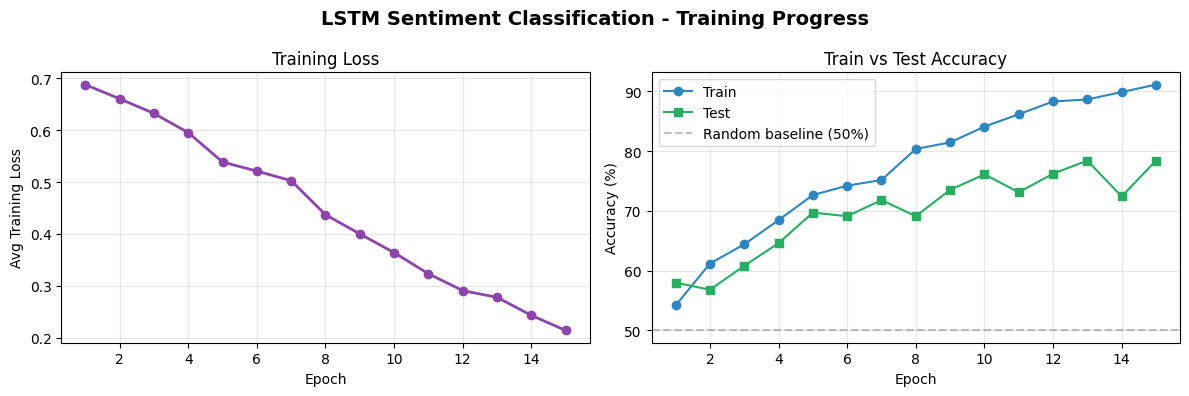

CHART INTERPRETATION:

LEFT PANEL (Training Loss):
  Starting loss ~ 0.69: for an untrained binary classifier outputting ~0.5,
  BCE loss ~ -log(0.5) = 0.69. A higher starting loss suggests the initial
  random weights are biased toward one class.
  The loss decreases steadily, confirming the model IS learning patterns.
  If loss plateaus early: learning rate too low. If it oscillates: lr too high.

RIGHT PANEL (Accuracy):
  Final train accuracy: 91.1%
  Final test accuracy:  78.4%
  Train-test gap: 12.7%
  -> Moderate gap: some overfitting but the model is still useful.
  Both curves should be ABOVE 50% (gray baseline). If test stays near
  50%, the model hasn't learned anything useful.


In [146]:
# ============================================================
# PLOT TRAINING CURVES
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, NUM_EPOCHS+1), train_losses, 'o-', color='#8E44AD', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Avg Training Loss')
ax1.set_title('Training Loss')
ax1.grid(alpha=0.3)

ax2.plot(range(1, NUM_EPOCHS+1), [a*100 for a in train_accs], 'o-', color='#2E86C1', label='Train')
ax2.plot(range(1, NUM_EPOCHS+1), [a*100 for a in test_accs], 's-', color='#27AE60', label='Test')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Random baseline (50%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Train vs Test Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('LSTM Sentiment Classification - Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("CHART INTERPRETATION:")
print()
print("LEFT PANEL (Training Loss):")
print(f"  Starting loss ~ {train_losses[0]:.2f}: for an untrained binary classifier outputting ~0.5,")
print(f"  BCE loss ~ -log(0.5) = 0.69. A higher starting loss suggests the initial")
print(f"  random weights are biased toward one class.")
print(f"  The loss decreases steadily, confirming the model IS learning patterns.")
print(f"  If loss plateaus early: learning rate too low. If it oscillates: lr too high.")
print()
print("RIGHT PANEL (Accuracy):")
gap = train_accs[-1] - test_accs[-1]
print(f"  Final train accuracy: {train_accs[-1]*100:.1f}%")
print(f"  Final test accuracy:  {test_accs[-1]*100:.1f}%")
print(f"  Train-test gap: {gap*100:.1f}%")
if gap > 0.15:
    print(f"  -> Gap > 15%: OVERFITTING. The model memorises training data")
    print(f"     but doesn't fully generalise. More data or stronger dropout would help.")
elif gap < 0.05:
    print(f"  -> Small gap: good generalisation! Patterns transfer to unseen data.")
else:
    print(f"  -> Moderate gap: some overfitting but the model is still useful.")
print(f"  Both curves should be ABOVE 50% (gray baseline). If test stays near")
print(f"  50%, the model hasn't learned anything useful.")

### Step 4: Test with Custom Sentences

In [147]:
# ============================================================
# INTERACTIVE PREDICTION
# ============================================================

def predict_sentiment(review_text, verbose=True):
    """Predict sentiment for a single review."""
    model2.eval()
    with torch.no_grad():
        tokens = tokenize(review_text)
        indices = [word2idx.get(w, UNK_IDX) for w in tokens]
        n_unk = sum(1 for idx in indices if idx == UNK_IDX)
        original_len = len(indices)

        if len(indices) < MAX_LEN:
            indices += [PAD_IDX] * (MAX_LEN - len(indices))
        else:
            indices = indices[:MAX_LEN]
            original_len = MAX_LEN

        tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)
        length = torch.tensor([original_len])
        score = model2(tensor, length).item()
        label = "Positive" if score >= 0.5 else "Negative"

        if verbose:
            emoji = ":)" if score >= 0.5 else ":("
            print(f'Review:    "{review_text}"')
            print(f'Tokens:    {len(tokens)} words ({n_unk} unknown/OOV)')
            print(f'Sentiment: {label} {emoji}  (score: {score:.4f})')
            print()

        return score, label


print("=" * 70)
print("LSTM SENTIMENT PREDICTIONS")
print("=" * 70 + "\n")

predict_sentiment("This movie was fantastic and beautifully directed.")
predict_sentiment("Terrible acting and a completely boring plot.")
predict_sentiment("The film had some good moments but overall it was mediocre.")
predict_sentiment("One of the best movies I have ever seen in my life.")
predict_sentiment("An absolute waste of time. Do not watch this.")
predict_sentiment("A gripping thriller with outstanding performances from the entire cast.")
predict_sentiment("I fell asleep halfway through. Nothing happens in this movie.")

LSTM SENTIMENT PREDICTIONS

Review:    "This movie was fantastic and beautifully directed."
Tokens:    7 words (0 unknown/OOV)
Sentiment: Positive :)  (score: 0.9786)

Review:    "Terrible acting and a completely boring plot."
Tokens:    7 words (0 unknown/OOV)
Sentiment: Negative :(  (score: 0.0016)

Review:    "The film had some good moments but overall it was mediocre."
Tokens:    11 words (0 unknown/OOV)
Sentiment: Negative :(  (score: 0.1336)

Review:    "One of the best movies I have ever seen in my life."
Tokens:    12 words (0 unknown/OOV)
Sentiment: Positive :)  (score: 0.9973)

Review:    "An absolute waste of time. Do not watch this."
Tokens:    9 words (0 unknown/OOV)
Sentiment: Negative :(  (score: 0.0031)

Review:    "A gripping thriller with outstanding performances from the entire cast."
Tokens:    10 words (0 unknown/OOV)
Sentiment: Positive :)  (score: 0.7296)

Review:    "I fell asleep halfway through. Nothing happens in this movie."
Tokens:    10 words (0 unknown/OO

(0.012594622559845448, 'Negative')

---
## Model Evaluation and Metrics

| Metric | What It Measures | Why It Matters |
|--------|------------------|----------------|
| **Accuracy** | Overall correctness | Simple but can mislead with imbalanced classes |
| **Precision** | Of predicted positives, how many truly are? | Important when false positives are costly |
| **Recall** | Of actual positives, how many were caught? | Important when missing positives is costly |
| **F1 Score** | Harmonic mean of Precision and Recall | Balances both; best single metric |
| **Confusion Matrix** | Full TP, FP, TN, FN breakdown | Shows exactly where errors occur |

In [148]:
# ============================================================
# COMPREHENSIVE EVALUATION
# ============================================================

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

def evaluate_model(model, loader):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, labels, lengths = batch
            inputs = inputs.to(device)
            scores = model(inputs, lengths).squeeze(1).cpu()
            all_scores.extend(scores.tolist())
            all_labels.extend(labels.tolist())
    return np.array(all_scores), np.array(all_labels)

test_scores, test_labels = evaluate_model(model2, test_loader)
test_preds = (test_scores >= 0.5).astype(int)

print("=" * 55)
print("CLASSIFICATION REPORT - LSTM on Test Set")
print("=" * 55)
print(classification_report(test_labels, test_preds,
                            labels=[0, 1],
                            target_names=['Negative', 'Positive'],
                            digits=3, zero_division=0))

unique_preds = np.unique(test_preds)
if len(unique_preds) == 1:
    print(f"WARNING: Model predicts only class {int(unique_preds[0])} for all samples.")

CLASSIFICATION REPORT - LSTM on Test Set
              precision    recall  f1-score   support

    Negative      0.789     0.789     0.789       512
    Positive      0.779     0.779     0.779       488

    accuracy                          0.784      1000
   macro avg      0.784     0.784     0.784      1000
weighted avg      0.784     0.784     0.784      1000



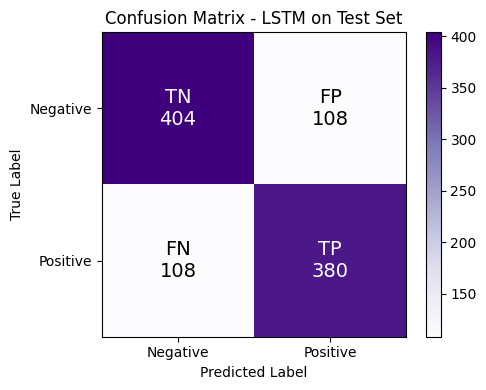


CONFUSION MATRIX INTERPRETATION:
  TN=404: Negative reviews correctly classified as Negative
  FP=108: Negative reviews WRONGLY classified as Positive (Type I error)
  FN=108: Positive reviews WRONGLY classified as Negative (Type II error)
  TP=380: Positive reviews correctly classified as Positive
  Ideal: large numbers on the diagonal (TN, TP), small off-diagonal (FP, FN).
  Errors are balanced between both types.


In [149]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(test_labels, test_preds, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Purples')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'])
ax.set_yticklabels(['Negative', 'Positive'])
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - LSTM on Test Set')

labels_text = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        colour = 'white' if cm[i, j] > cm.max()/2 else 'black'
        ax.text(j, i, f"{labels_text[i][j]}\n{cm[i,j]}",
                ha='center', va='center', color=colour, fontsize=14)

plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nCONFUSION MATRIX INTERPRETATION:")
print(f"  TN={tn}: Negative reviews correctly classified as Negative")
print(f"  FP={fp}: Negative reviews WRONGLY classified as Positive (Type I error)")
print(f"  FN={fn}: Positive reviews WRONGLY classified as Negative (Type II error)")
print(f"  TP={tp}: Positive reviews correctly classified as Positive")
print(f"  Ideal: large numbers on the diagonal (TN, TP), small off-diagonal (FP, FN).")
if fp > fn:
    print(f"  This model over-predicts positive sentiment (more FP than FN).")
elif fn > fp:
    print(f"  This model tends to miss positive reviews (more FN than FP).")
else:
    print(f"  Errors are balanced between both types.")

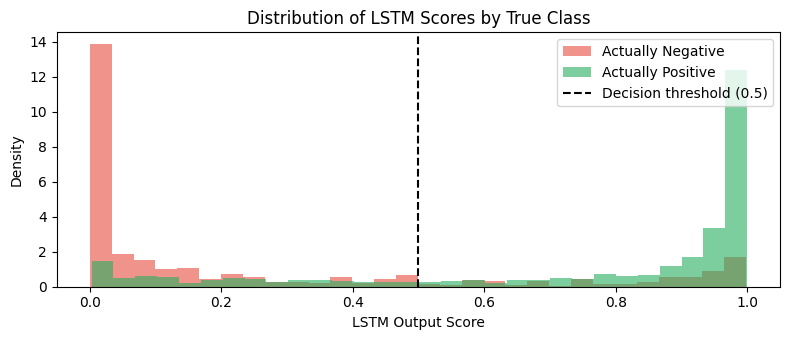

SCORE DISTRIBUTION INTERPRETATION:
  Negative reviews: mean score = 0.246 (ideal: close to 0)
  Positive reviews: mean score = 0.757 (ideal: close to 1)
  Separation: 0.511 (larger = better, perfect = 1.0)
  Good separation: the LSTM has learned to distinguish sentiment.
  The two distributions sit on opposite sides of 0.5.


In [150]:
# ============================================================
# SCORE DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(8, 3.5))
neg_scores = test_scores[test_labels == 0]
pos_scores = test_scores[test_labels == 1]

ax.hist(neg_scores, bins=30, alpha=0.6, color='#E74C3C', label='Actually Negative', density=True)
ax.hist(pos_scores, bins=30, alpha=0.6, color='#27AE60', label='Actually Positive', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', label='Decision threshold (0.5)')
ax.set_xlabel('LSTM Output Score')
ax.set_ylabel('Density')
ax.set_title('Distribution of LSTM Scores by True Class')
ax.legend()
plt.tight_layout()
plt.show()

sep = abs(pos_scores.mean() - neg_scores.mean())
print(f"SCORE DISTRIBUTION INTERPRETATION:")
print(f"  Negative reviews: mean score = {neg_scores.mean():.3f} (ideal: close to 0)")
print(f"  Positive reviews: mean score = {pos_scores.mean():.3f} (ideal: close to 1)")
print(f"  Separation: {sep:.3f} (larger = better, perfect = 1.0)")
if sep > 0.4:
    print(f"  Good separation: the LSTM has learned to distinguish sentiment.")
    print(f"  The two distributions sit on opposite sides of 0.5.")
elif sep > 0.15:
    print(f"  Moderate separation: the model is learning but overlap near 0.5")
    print(f"  means many reviews are classified with low confidence.")
else:
    print(f"  Poor separation: both classes produce similar scores.")

### Key Takeaways

1. **The LSTM is a drop-in replacement for the RNN.** Changing `nn.RNN` to `nn.LSTM` and unpacking `(hidden, cell)` instead of `hidden` is the core change.

2. **Architecture alone isn't enough.** The jump from 500 to 5,000 samples + dropout + gradient clipping is what makes the model actually work on custom sentences.

3. **Design decisions are interconnected:** larger data supports a larger model, which needs regularisation (dropout, weight decay), which needs adjusted learning rate.

4. **Evaluation must go beyond training loss.** The classification report, confusion matrix, and score distribution give the full picture.

---

# Exercises

These exercises build on the LSTM tutorial. They progress from easy modifications to advanced challenges.

## Exercise 1 - LSTM vs RNN Side-by-Side (Easy)

Compare the LSTM and RNN directly on the next-word prediction task.

**Task:**
1. Copy the `NextWordRNN` class from the RNN tutorial (use `nn.RNN` instead of `nn.LSTM`)
2. Train both models for 150 epochs with identical hyperparameters
3. Plot both loss curves on the same graph
4. Print the parameter count for both

**Questions:**
- Which converges faster on this toy task?
- How many more parameters does the LSTM have?
- On a 9-word sentence, does the extra capacity matter?

In [151]:
# EXERCISE 1 - Your code here



## Exercise 2 - Inspect the Gates (Medium)

The LSTM's power comes from its **gates**. Let's peek inside.

**Task:**
1. Build a manual LSTM cell using `nn.LSTMCell` (not `nn.LSTM`)
2. At each time step, record `(h_t, c_t)`
3. Manually compute gate activations and create a heatmap (words x 4 gates)

**Questions:**
- Are forget gate values close to 0 or 1? What does that mean?
- Does the input gate activate more for content words than function words?

In [152]:
# EXERCISE 2 - Your code here

# Hint: nn.LSTMCell(input_size, hidden_size) processes one step at a time
# h_t, c_t = lstm_cell(x_t, (h_prev, c_prev))
# The weight_ih matrix is stacked as [W_ii, W_if, W_ig, W_io]



## Exercise 3 - Tune the Dropout Rate (Medium)

Our model uses `dropout=0.3`. Is this optimal?

**Task:** Train with dropout rates 0.0, 0.1, 0.3, 0.5, 0.7 and plot test accuracy vs dropout.

**Questions:**
- What dropout gives the best test accuracy?
- At dropout=0.0, how large is the train-test gap?
- At dropout=0.7, does training even converge?

In [153]:
# EXERCISE 3 - Your code here



## Exercise 4 - Data Size Ablation (Medium)

How much data does the LSTM need to work well?

**Task:** Train on 500, 1000, 2000, 5000, 10000 reviews. Plot test accuracy vs data size.

**Questions:**
- At what size does the model consistently beat 50%?
- Is there a point of diminishing returns?

In [154]:
# EXERCISE 4 - Your code here



## Exercise 5 - GRU Comparison (Medium)

The **GRU** merges the forget and input gates, and combines the cell and hidden states.

**Task:** Create `SentimentGRU` with `nn.GRU`, train, and compare with the LSTM.

| Model | Parameters | Test Accuracy | Test F1 |
|-------|-----------|---------------|---------|  
| LSTM | | | |
| GRU | | | |

In [155]:
# EXERCISE 5 - Your code here

# GRU returns (output, hidden) - no cell state, same as nn.RNN



## Exercise 6 - Long-Range Dependency Test (Hard)

Demonstrate *why* LSTMs exist.

**Task:** Create synthetic data where the label depends on the FIRST token of a long sequence (remaining tokens are noise). Train RNN, LSTM, and GRU across lengths [10, 25, 50, 100, 200]. Plot accuracy vs length.

**Expected:** RNN accuracy degrades with length; LSTM maintains high accuracy.

In [156]:
# EXERCISE 6 - Your code here



## Exercise 7 - Reflection (No Code)

**Write 2-3 paragraphs for each:**

1. **Architecture selection:** You need to classify 300-word customer support emails by urgency (low/medium/high). Would you use RNN, LSTM, GRU, or Transformer? Consider: sequence length, data availability, compute budget, interpretability.

2. **Overfitting diagnosis:** If training loss drops to near zero in 2-3 epochs but test accuracy barely improves, describe three specific techniques (beyond more data) that reduce overfitting, and explain how each works.

3. **Cell state interpretation:** The cell state is called "long-term memory" but the heatmap shows it changes at every step. Is this description misleading? How would you explain it to a non-technical stakeholder?

*Write your answers here:*

**1. Architecture Selection**



**2. Overfitting Diagnosis**



**3. Cell State Interpretation**



---

## Further Reading

- **Foundational text:** Goodfellow, Bengio & Courville (2016) *Deep Learning*, Chapter 10
- **LSTM original paper:** Hochreiter & Schmidhuber (1997) *Long Short-Term Memory*
- **Intuitive guide:** Colah's blog — [Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- **GRU paper:** Cho et al. (2014) *Learning Phrase Representations using RNN Encoder-Decoder*
- **Practical RNNs:** Karpathy (2015) — [The Unreasonable Effectiveness of RNNs](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
- **PyTorch docs:** [nn.LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html) | [nn.Embedding](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html) | [nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)

---

*Notebook prepared for the MSc Applied AI — AI & Deep Learning Module.*